## Testing ground for motif search algorithms

networkx hello world:

In [574]:
G = nx.fast_gnp_random_graph(10, 0.4, seed=12)
H = nx.fast_gnp_random_graph(5, 0.7, seed=14)
# nx.draw_spring(G, with_labels=True)

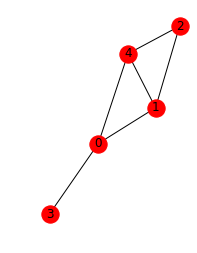

In [1405]:
plt.subplot(121)
nx.draw_spring(H, with_labels=True)

from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Show/hide code"></form>''')



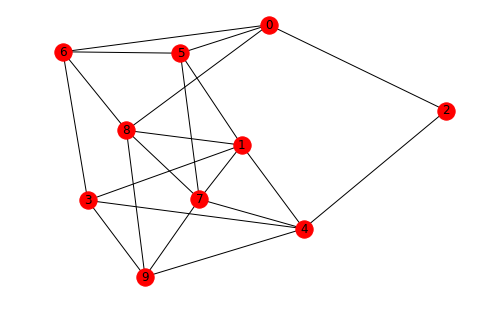

In [350]:
# plt.subplot(121)
nx.draw_spring(G, with_labels=True)

In [ ]:
H2 = nx.Graph()
H2.add_nodes_from([0,1,2,3,4,5])
H2.add_edges_from([(0,1), (1, 2), (2, 0), (4, 3), (3, 5), (5, 4), (0, 3)])
nx.draw_spring(H2, with_labels=True)

## CONSOLE

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import functions as fn
import matplotlib.pyplot as plt
import importlib
import numpy.lib.recfunctions as rfn
importlib.reload(fn)
G = nx.fast_gnp_random_graph(10, 0.4, seed=12)
H = nx.fast_gnp_random_graph(5, 0.7, seed=14)

######################################################################

instances = fn.findSubgraphInstances(H, G, False)
[k.getMap() for k in instances]

In [ ]:
f1 = fn.Map([(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5)])
f2 = fn.Map([(0, 0), (1, 1), (2, 2), (3, 3), (4, 5), (5, 4)])
f3 = fn.Map([(0, 0), (1, 2), (2, 1), (3, 3), (4, 4), (5, 5)])
f4 = fn.Map([(0, 0), (1, 2), (2, 1), (3, 3), (4, 5), (5, 4)])
f5 = fn.Map([(0, 3), (1, 4), (2, 5), (3, 0), (4, 1), (5, 2)])
f6 = fn.Map([(0, 3), (1, 5), (2, 4), (3, 0), (4, 2), (5, 1)])

autH2 = [f1, f2, f3, f4, f5, f6]  # set of automorphisms of H2
eq = fn.findEquivalenceClasses(autH2)
M = fn.symmetryConditions(autH2)

[t for t in f1.getMap()]

## Flipping graph edges

The two random graphs $F = (V_F, E_F)$ and $F2 = (V_{F2}, E_{F2})$ below are edge-inverses of each other:

$V_F = V_{F2}$ 

$(u, v) \in E_F \iff (u, v) \notin E_{F2}$

I was wondering what would happen to the 3-core of a graph if the edges were flipped in this way. More generally, at what k-core does it become advantageous to flip the core of the graph? Then we could flip the dense core and get a doughnut-shaped graph (to go along with the onion).


I made some plots below to try to answer this.

In [1406]:
from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Show/hide code"></form>''')



Onion Decomposition for F


{8: {'coreness': 2, 'layer': 2},
 2: {'coreness': 3, 'layer': 3},
 7: {'coreness': 3, 'layer': 4},
 9: {'coreness': 3, 'layer': 4},
 3: {'coreness': 3, 'layer': 5},
 5: {'coreness': 3, 'layer': 5},
 0: {'coreness': 3, 'layer': 6},
 1: {'coreness': 3, 'layer': 6},
 4: {'coreness': 3, 'layer': 6},
 6: {'coreness': 3, 'layer': 6}}

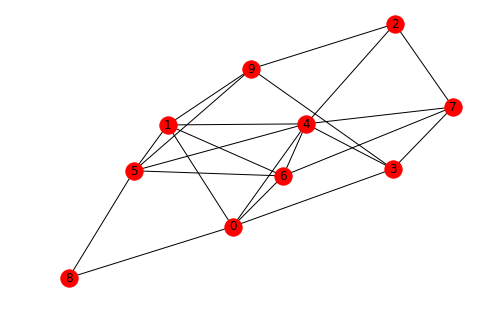

In [1408]:
F = nx.fast_gnp_random_graph(10, 0.5, seed = 1)
nx.draw_spring(F, with_labels=True)
print('Onion Decomposition for F')
fn.onionDecompose(F)

Onion Decomposition for F2


{4: {'coreness': 2, 'layer': 2},
 0: {'coreness': 4, 'layer': 3},
 1: {'coreness': 4, 'layer': 3},
 5: {'coreness': 4, 'layer': 3},
 6: {'coreness': 4, 'layer': 3},
 9: {'coreness': 4, 'layer': 3},
 2: {'coreness': 4, 'layer': 4},
 3: {'coreness': 4, 'layer': 4},
 7: {'coreness': 4, 'layer': 4},
 8: {'coreness': 4, 'layer': 4}}

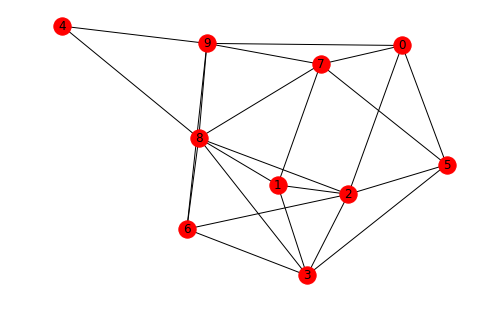

In [1409]:
F = nx.fast_gnp_random_graph(10, 0.5, seed = 1)

F2 = nx.Graph()
F2.add_nodes_from(F.nodes())
F2.add_edges_from([i for i in nx.non_edges(F)])
nx.draw_spring(F2, with_labels=True)
print('Onion Decomposition for F2')
fn.onionDecompose(F2)

In [ ]:
import matplotlib.pyplot as plt

kvals = [8, 16, 32, 64, 128]
m = 1000
n = len(kvals)
x_axis = range(m)
graphCoreness = np.zeros([n, m])
flippedCoreness = np.zeros([n, m])

for l, k in enumerate(kvals):
    for i in x_axis:
        F = nx.fast_gnp_random_graph(k, i/m)
        F2 = nx.Graph()
        F2.add_nodes_from(F.nodes())
        F2.add_edges_from([j for j in nx.non_edges(F)])

        od_F = fn.onionDecompose(F)
        od_F2 = fn.onionDecompose(F2)

        graphCoreness[l, i] = np.average([k['coreness'] for k in od_F.values()])
        flippedCoreness[l, i] = np.average([k['coreness'] for k in od_F2.values()])


Below are plotted the average coreness of graphs (in blue) of sizes 8, 16, 32, 64 and 128 and that of their edge-flipped inverses (in red).

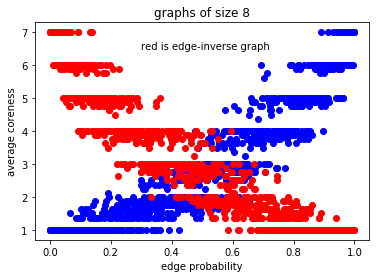

In [1400]:
x_axis = range(m)
x_axis = [i/m for i in x_axis]
plt.plot(x_axis, graphCoreness[0,], 'bo', x_axis, flippedCoreness[0,], 'ro')
plt.text(0.3, 6.5, 'red is edge-inverse graph')
plt.xlabel('edge probability')
plt.ylabel('average coreness')
plt.title('graphs of size 8')
plt.show()

from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Show/hide code"></form>''')



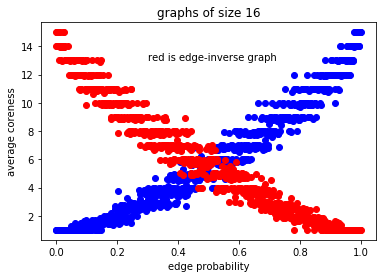

In [1362]:
plt.plot(x_axis, graphCoreness[1,], 'bo', x_axis, flippedCoreness[1,], 'ro')
plt.text(0.3, 13, 'red is edge-inverse graph')
plt.xlabel('edge probability')
plt.ylabel('average coreness')
plt.title('graphs of size 16')
plt.show()

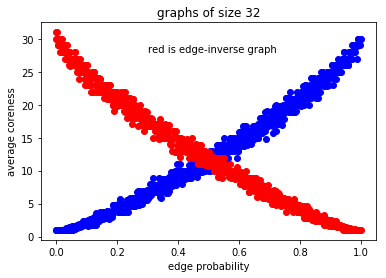

In [1363]:
plt.plot(x_axis, graphCoreness[2,], 'bo', x_axis, flippedCoreness[2,], 'ro')
plt.text(0.3, 28, 'red is edge-inverse graph')
plt.xlabel('edge probability')
plt.ylabel('average coreness')
plt.title('graphs of size 32')
plt.show()

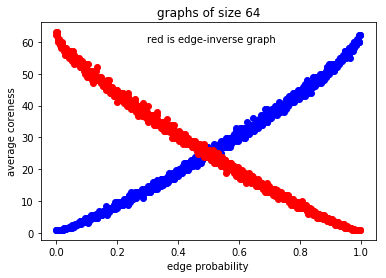

In [1365]:
plt.plot(x_axis, graphCoreness[3,], 'bo', x_axis, flippedCoreness[3,], 'ro')
plt.text(0.3, 60, 'red is edge-inverse graph')
plt.xlabel('edge probability')
plt.ylabel('average coreness')
plt.title('graphs of size 64')
plt.show()

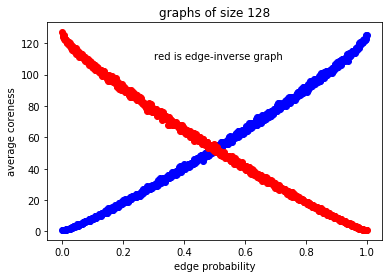

In [1366]:
plt.plot(x_axis, graphCoreness[4,], 'bo', x_axis, flippedCoreness[4,], 'ro')
plt.text(0.3, 110, 'red is edge-inverse graph')
plt.xlabel('edge probability')
plt.ylabel('average coreness')
plt.title('graphs of size 128')
plt.show()

To find the "equal-coreness" value, the averages of all points between $p = 0.485$ and $p = 0.515$ are taken for each of the above plots, and these averages are plotted against the graph size below (in blue). A linear regression is shown in red. We can see the blue curve is slightly convex.

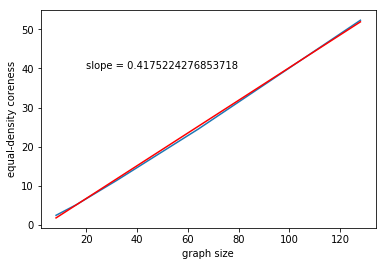

In [1387]:
from scipy import stats

avgVals = np.zeros(n)

for i, k in enumerate(kvals):
    avgVals[i] = np.average(graphCoreness[i, range(int(m/2) - 15, int(m/2) + 15)])

slope, intercept, r_value, p_value, std_err = stats.linregress(kvals, avgVals)
    
plt.plot(kvals, avgVals, kvals, [k*slope + intercept for k in kvals], 'r')
plt.text(20, 40, 'slope = ' + str(slope))
plt.xlabel('graph size')
plt.ylabel('equal-density coreness')
plt.show()


The same experiment was done again using less points (100 vs. 1000 for the above plots) but with larger graphs. Here is shown the equal-coreness value for graphs of sizes up to 1024. If you observe the blue line carefully, it still curves upwards very slightly. Maybe this slope actually goes to 0.5 in the limit.

In [1389]:
kvals2 = [8, 16, 32, 64, 128, 512, 1024]
m2 = 100
n2 = len(kvals2)
x_axis2 = range(m2)
graphCoreness2 = np.zeros([n2, m2])
flippedCoreness2 = np.zeros([n2, m2])

for l, k in enumerate(kvals2):
    for i in x_axis2:
        F = nx.fast_gnp_random_graph(k, i/m2)
        F2 = nx.Graph()
        F2.add_nodes_from(F.nodes())
        F2.add_edges_from([j for j in nx.non_edges(F)])

        od_F = fn.onionDecompose(F)
        od_F2 = fn.onionDecompose(F2)

        graphCoreness2[l, i] = np.average([k['coreness'] for k in od_F.values()])
        flippedCoreness2[l, i] = np.average([k['coreness'] for k in od_F2.values()])


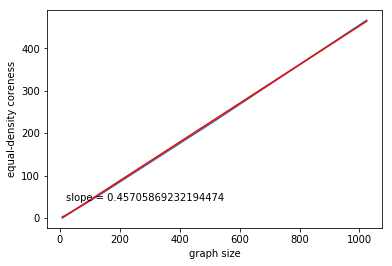

In [1391]:
avgVals2 = np.zeros(n2)

for i, k in enumerate(kvals2):
    avgVals2[i] = np.average(graphCoreness2[i, range(int(m2/2) - 15, int(m2/2) + 15)])

slope, intercept, r_value, p_value, std_err = stats.linregress(kvals2, avgVals2)
    
plt.plot(kvals2, avgVals2, kvals2, [k*slope + intercept for k in kvals2], 'r')
plt.text(20, 40, 'slope = ' + str(slope))
plt.xlabel('graph size')
plt.ylabel('equal-density coreness')
plt.show()

In [1399]:
from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Show/hide code"></form>''')



So, if we have a size k graph, when we hit the $0.457k$-core, it may be better off if we flip its edges and carry out the analysis inside with the query graph inverted.